# Improving Frozen Foundation-Model TME Classification

This experiment addresses the low macro-F1 from the initial raw probe without fine-tuning
either encoder. It compares two independent pathology foundation models, repairs
the unsupported label space, and selects preprocessing/regularization using
**nested leave-one-slide-out validation**.

## tl;dr

> **Phikon is the stronger frozen encoder, but the dataset—not model capacity—is
> now the main bottleneck.** Under nested slide-held-out validation, Phikon reaches
> **0.320 macro-F1** on all four labels versus **0.294** for Kaiko and **0.187** for
> a fold-matched majority baseline. Excluding the ambiguous `other` label raises
> Phikon to **0.366** and Kaiko to **0.326**, but retains only **39.0%** of spots.
> The weakest Phikon fold remains **0.227**, so the result is improved rather than
> solved. Hyperparameters are selected using only the three training slides in
> each outer fold.

## Context & Methods

### Changes from the initial probe

1. Compare **Kaiko ViT-S/16** (384-D) with **Phikon ViT-B** (768-D).
2. Evaluate both the original four-class task and a three-class task that excludes
   ambiguous `other` spots.
3. Test raw, L2-normalized, and transductive slide-z-scored + L2 embeddings.
4. Select the transform and logistic regularization inside nested slide folds.
5. Include a majority-class macro-F1 baseline in every outer fold.

### Key assumptions

- Slide-wise standardization uses no target labels, but it does use the complete
  target-slide feature distribution. It is valid for whole-slide batch inference,
  not isolated patch inference.
- Excluding `other` improves label confidence but reduces coverage. Four-class and
  three-class F1 values therefore answer different questions and are not directly
  interchangeable.
- Both checkpoints are research/non-commercial. Results remain methodological,
  not decision-grade.

Model sources: [Kaiko](https://huggingface.co/1aurent/vit_small_patch16_224.kaiko_ai_towards_large_pathology_fms),
[Phikon](https://huggingface.co/owkin/phikon).

## Setup

In [1]:
from pathlib import Path
import os, sys

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
ROOT = Path.cwd()
if not (ROOT / "projects" / "spatial-pharma-dl").exists():
    ROOT = Path.cwd().resolve().parents[2]
PHARMA = ROOT / "projects" / "spatial-pharma-dl"
sys.path[:0] = [str(ROOT), str(PHARMA)]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, silhouette_score

from src.data import load_config, pharma_outputs_dir
from src.foundation import foundation_model_spec, load_or_extract_slide_embeddings
from src.foundation_eval import (
    DEFAULT_CANDIDATES,
    TASK_CLASSES,
    nested_loso_classification,
    preprocess_slide_embeddings,
)

SEED = 0
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"kaiko_vits16": "#326B91", "phikon": "#C4912E"}

cfg = load_config()
slides = cfg["cohorts"]["oncology"]
model_names = ["kaiko_vits16", "phikon"]
tasks = ["all_4class", "confident_3class"]
figure_dir = pharma_outputs_dir() / "foundation_v2"
figure_dir.mkdir(parents=True, exist_ok=True)
print("Slides:", len(slides), "| models:", model_names, "| tasks:", tasks)

Slides: 4 | models: ['kaiko_vits16', 'phikon'] | tasks: ['all_4class', 'confident_3class']


## Data

### 1. Audit class support and three-class coverage

tme_class,immune_enriched,other,stromal,tumor_epithelial
slide_id,,,,
Parent_Visium_Human_BreastCancer,0,1859,1001,1128
V1_Breast_Cancer_Block_A_Section_1,480,2820,327,171
V1_Breast_Cancer_Block_A_Section_2,431,3064,357,133
Visium_FFPE_Human_Breast_Cancer,251,1167,967,131


,slide_id,sum,count,mean,excluded_other
0,Parent_Visium_Human_BreastCancer,2129,3988,0.534,1859
1,V1_Breast_Cancer_Block_A_Section_1,978,3798,0.258,2820
2,V1_Breast_Cancer_Block_A_Section_2,921,3985,0.231,3064
3,Visium_FFPE_Human_Breast_Cancer,1349,2516,0.536,1167


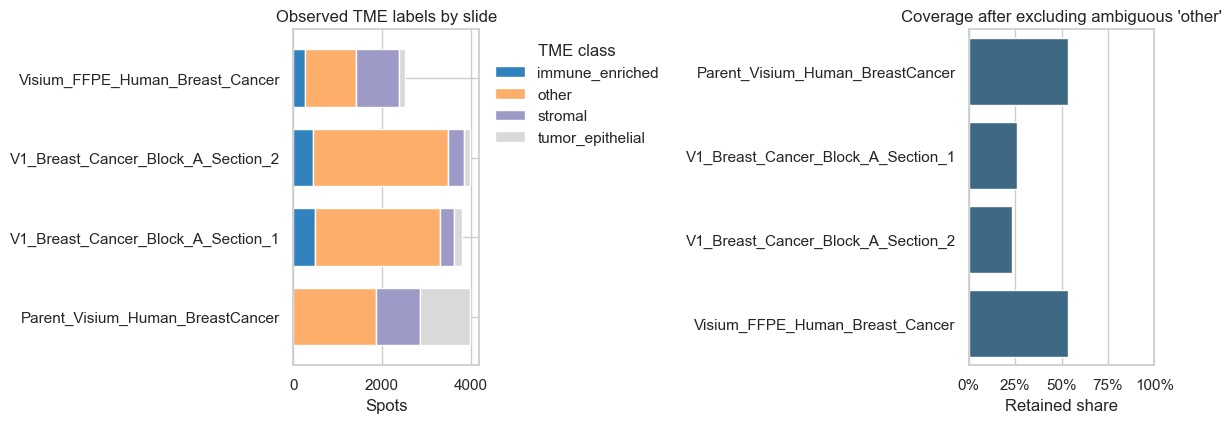

In [2]:
labels = pd.concat(
    [pd.read_parquet(pharma_outputs_dir() / f"labels_{s}.parquet") for s in slides],
    ignore_index=True,
)
support = pd.crosstab(labels["slide_id"], labels["tme_class"])
display(support)

supported = set(TASK_CLASSES["confident_3class"])
coverage = (
    labels.assign(confident=labels["tme_class"].isin(supported))
    .groupby("slide_id", observed=True)["confident"]
    .agg(["sum", "count", "mean"])
    .reset_index()
)
coverage["excluded_other"] = coverage["count"] - coverage["sum"]
display(coverage.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
support.plot(kind="barh", stacked=True, ax=axes[0], colormap="tab20c", width=.72)
axes[0].set(title="Observed TME labels by slide", xlabel="Spots", ylabel="")
axes[0].legend(title="TME class", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
sns.barplot(data=coverage, y="slide_id", x="mean", color="#326B91", ax=axes[1])
axes[1].set(title="Coverage after excluding ambiguous 'other'", xlabel="Retained share", ylabel="", xlim=(0, 1))
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.savefig(figure_dir / "01_label_support_and_coverage.png", dpi=170, bbox_inches="tight")
plt.show()

### 2. Load validated cached embeddings for both encoders

In [3]:
all_model_data = {}
embedding_audit = []
for model_name in model_names:
    model_cfg = load_config()
    model_cfg["foundation"]["model"] = model_name
    _, spec = foundation_model_spec(model_cfg)
    slide_data = {}
    for slide_id in slides:
        embeddings, aligned = load_or_extract_slide_embeddings(slide_id, labels, cfg=model_cfg)
        assert embeddings.shape == (len(aligned), spec.embedding_dim)
        assert np.isfinite(embeddings).all()
        assert aligned["spot_id"].is_unique
        slide_data[slide_id] = (embeddings, aligned)
        embedding_audit.append({
            "model": model_name,
            "slide_id": slide_id,
            "spots": len(aligned),
            "embedding_dim": embeddings.shape[1],
            "license": spec.license,
        })
    all_model_data[model_name] = slide_data

audit = pd.DataFrame(embedding_audit)
display(audit)

,model,slide_id,spots,embedding_dim,license
0,kaiko_vits16,V1_Breast_Cancer_Block_A_Section_1,3798,384,kaiko-non-commercial
1,kaiko_vits16,V1_Breast_Cancer_Block_A_Section_2,3985,384,kaiko-non-commercial
2,kaiko_vits16,Visium_FFPE_Human_Breast_Cancer,2516,384,kaiko-non-commercial
3,kaiko_vits16,Parent_Visium_Human_BreastCancer,3988,384,kaiko-non-commercial
4,phikon,V1_Breast_Cancer_Block_A_Section_1,3798,768,owkin-non-commercial
5,phikon,V1_Breast_Cancer_Block_A_Section_2,3985,768,owkin-non-commercial
6,phikon,Visium_FFPE_Human_Breast_Cancer,2516,768,owkin-non-commercial
7,phikon,Parent_Visium_Human_BreastCancer,3988,768,owkin-non-commercial


## Results

### 3. Run nested LOSO model selection and outer evaluation

In [4]:
result_frames = []
all_details = {}
for model_name in model_names:
    for task in tasks:
        print("Evaluating", model_name, task)
        frame, details = nested_loso_classification(
            slides,
            all_model_data[model_name],
            task=task,
            candidates=DEFAULT_CANDIDATES,
            seed=SEED,
        )
        frame.insert(0, "model", model_name)
        result_frames.append(frame)
        all_details[(model_name, task)] = details

results = pd.concat(result_frames, ignore_index=True)
results.to_csv(figure_dir / "nested_loso_results.csv", index=False)
display(results.round(3))

Evaluating kaiko_vits16 all_4class


Evaluating kaiko_vits16 confident_3class


Evaluating phikon all_4class


Evaluating phikon confident_3class


,model,fold,held_out_slide,task,n_train,n_test,coverage,selected_candidate,inner_macro_f1,macro_f1,balanced_accuracy,majority_macro_f1,majority_balanced_accuracy
0,kaiko_vits16,0,V1_Breast_Cancer_Block_A_Section_1,all_4class,10489,3798,1.000,slide_zscore_l2|C=0.01|weight=balanced,0.236,0.387,0.465,0.213,0.250
1,kaiko_vits16,1,V1_Breast_Cancer_Block_A_Section_2,all_4class,10302,3985,1.000,slide_zscore_l2|C=0.01|weight=balanced,0.246,0.265,0.267,0.217,0.250
2,kaiko_vits16,2,Visium_FFPE_Human_Breast_Cancer,all_4class,11771,2516,1.000,slide_zscore_l2|C=0.01|weight=balanced,0.291,0.274,0.302,0.158,0.250
3,kaiko_vits16,3,Parent_Visium_Human_BreastCancer,all_4class,10299,3988,1.000,slide_zscore_l2|C=0.01|weight=balanced,0.337,0.249,0.349,0.159,0.333
4,kaiko_vits16,0,V1_Breast_Cancer_Block_A_Section_1,confident_3class,4399,978,0.258,slide_zscore_l2|C=0.01|weight=balanced,0.246,0.578,0.626,0.167,0.333
5,kaiko_vits16,1,V1_Breast_Cancer_Block_A_Section_2,confident_3class,4456,921,0.231,raw|C=0.01|weight=balanced,0.281,0.203,0.338,0.186,0.333
6,kaiko_vits16,2,Visium_FFPE_Human_Breast_Cancer,confident_3class,4028,1349,0.536,slide_zscore_l2|C=0.01|weight=balanced,0.393,0.298,0.327,0.278,0.333
7,kaiko_vits16,3,Parent_Visium_Human_BreastCancer,confident_3class,3248,2129,0.534,slide_zscore_l2|C=0.01|weight=balanced,0.543,0.227,0.355,0.213,0.500
8,phikon,0,V1_Breast_Cancer_Block_A_Section_1,all_4class,10489,3798,1.000,slide_zscore_l2|C=0.01|weight=balanced,0.209,0.450,0.503,0.213,0.250
9,phikon,1,V1_Breast_Cancer_Block_A_Section_2,all_4class,10302,3985,1.000,slide_zscore_l2|C=0.01|weight=balanced,0.274,0.307,0.313,0.217,0.250


### 4. Compare encoders, tasks, and fold-matched baselines

,task,model,mean_macro_f1,min_macro_f1,mean_balanced_accuracy,majority_macro_f1,mean_coverage,f1_lift_vs_majority
0,all_4class,kaiko_vits16,0.294,0.249,0.346,0.187,1.00,0.107
1,all_4class,phikon,0.320,0.247,0.375,0.187,1.00,0.133
2,confident_3class,kaiko_vits16,0.326,0.203,0.411,0.211,0.39,0.115
3,confident_3class,phikon,0.366,0.227,0.433,0.211,0.39,0.155


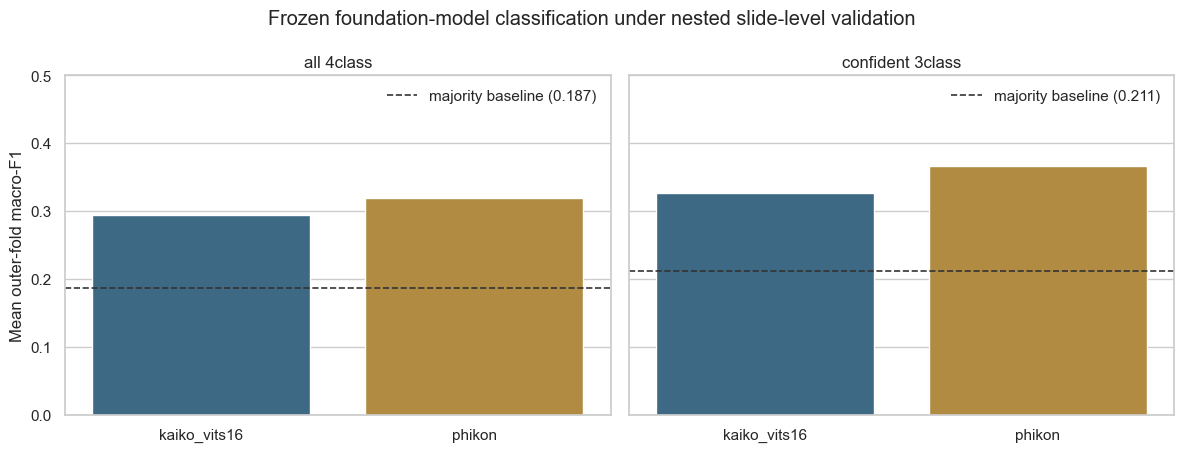

In [5]:
summary = (
    results.groupby(["task", "model"], observed=True)
    .agg(
        mean_macro_f1=("macro_f1", "mean"),
        min_macro_f1=("macro_f1", "min"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        majority_macro_f1=("majority_macro_f1", "mean"),
        mean_coverage=("coverage", "mean"),
    )
    .reset_index()
)
summary["f1_lift_vs_majority"] = summary["mean_macro_f1"] - summary["majority_macro_f1"]
display(summary.round(3))
summary.to_csv(figure_dir / "model_task_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, task in zip(axes, tasks):
    subset = summary[summary.task == task]
    sns.barplot(data=subset, x="model", y="mean_macro_f1", hue="model", palette=PALETTE, legend=False, ax=ax)
    baseline = subset["majority_macro_f1"].mean()
    ax.axhline(baseline, color="#333333", linestyle="--", linewidth=1.2, label=f"majority baseline ({baseline:.3f})")
    ax.set(title=task.replace("_", " "), xlabel="", ylabel="Mean outer-fold macro-F1", ylim=(0, max(.5, subset.mean_macro_f1.max() * 1.2)))
    ax.legend(frameon=False)
plt.suptitle("Frozen foundation-model classification under nested slide-level validation")
plt.tight_layout()
plt.savefig(figure_dir / "02_model_task_macro_f1.png", dpi=170, bbox_inches="tight")
plt.show()

### 5. Inspect fold stability

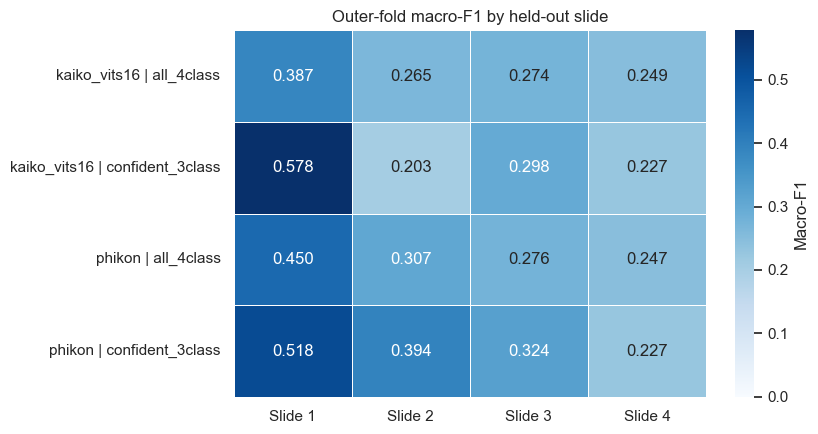

In [6]:
fold_view = results.copy()
fold_view["model_task"] = fold_view["model"] + " | " + fold_view["task"]
fold_view["slide"] = fold_view["held_out_slide"].map({s: f"Slide {i+1}" for i, s in enumerate(slides)})
heatmap = fold_view.pivot(index="model_task", columns="slide", values="macro_f1")

plt.figure(figsize=(8.5, 4.5))
sns.heatmap(heatmap, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=max(.5, heatmap.max().max()), linewidths=.5, cbar_kws={"label": "Macro-F1"})
plt.title("Outer-fold macro-F1 by held-out slide")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout()
plt.savefig(figure_dir / "03_fold_macro_f1_heatmap.png", dpi=170, bbox_inches="tight")
plt.show()

### 6. Verify what nested tuning selected

,model,task,selected_candidate,outer_folds_selected
0,kaiko_vits16,all_4class,slide_zscore_l2|C=0.01|weight=balanced,4
2,kaiko_vits16,confident_3class,slide_zscore_l2|C=0.01|weight=balanced,3
1,kaiko_vits16,confident_3class,raw|C=0.01|weight=balanced,1
3,phikon,all_4class,slide_zscore_l2|C=0.01|weight=balanced,4
5,phikon,confident_3class,slide_zscore_l2|C=0.01|weight=balanced,3
4,phikon,confident_3class,raw|C=0.01|weight=balanced,1


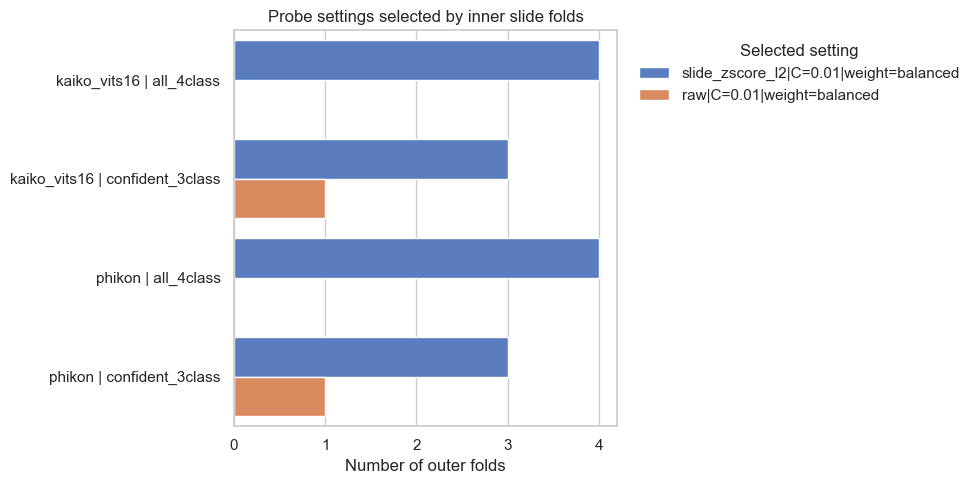

In [7]:
selection = (
    results.groupby(["model", "task", "selected_candidate"], observed=True)
    .size().rename("outer_folds_selected").reset_index()
    .sort_values(["model", "task", "outer_folds_selected"], ascending=[True, True, False])
)
display(selection)

selection_plot = selection.copy()
selection_plot["model_task"] = selection_plot["model"] + " | " + selection_plot["task"]
plt.figure(figsize=(10, 5))
sns.barplot(data=selection_plot, y="model_task", x="outer_folds_selected", hue="selected_candidate", palette="muted")
plt.title("Probe settings selected by inner slide folds")
plt.xlabel("Number of outer folds"); plt.ylabel("")
plt.legend(title="Selected setting", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.savefig(figure_dir / "04_nested_selection_counts.png", dpi=170, bbox_inches="tight")
plt.show()

### 7. Compare confident-class confusion patterns

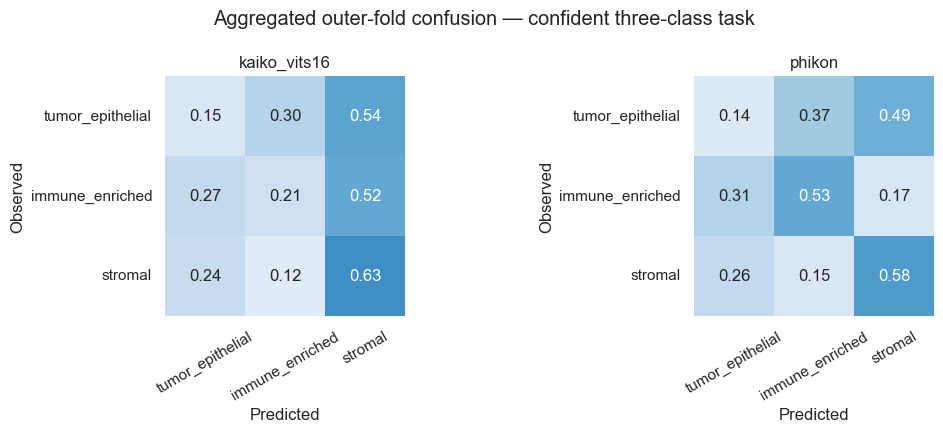

In [8]:
task = "confident_3class"
class_names = TASK_CLASSES[task]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, model_name in zip(axes, model_names):
    details = all_details[(model_name, task)]
    y_true = np.concatenate([details[f]["y_true"] for f in sorted(details)])
    y_pred = np.concatenate([details[f]["y_pred"] for f in sorted(details)])
    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)), normalize="true")
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True, cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set(title=model_name, xlabel="Predicted", ylabel="Observed")
    ax.tick_params(axis="x", rotation=30); ax.tick_params(axis="y", rotation=0)
plt.suptitle("Aggregated outer-fold confusion — confident three-class task")
plt.tight_layout()
plt.savefig(figure_dir / "05_confident_class_confusion.png", dpi=170, bbox_inches="tight")
plt.show()

### 8. Check whether normalization reduces slide structure

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


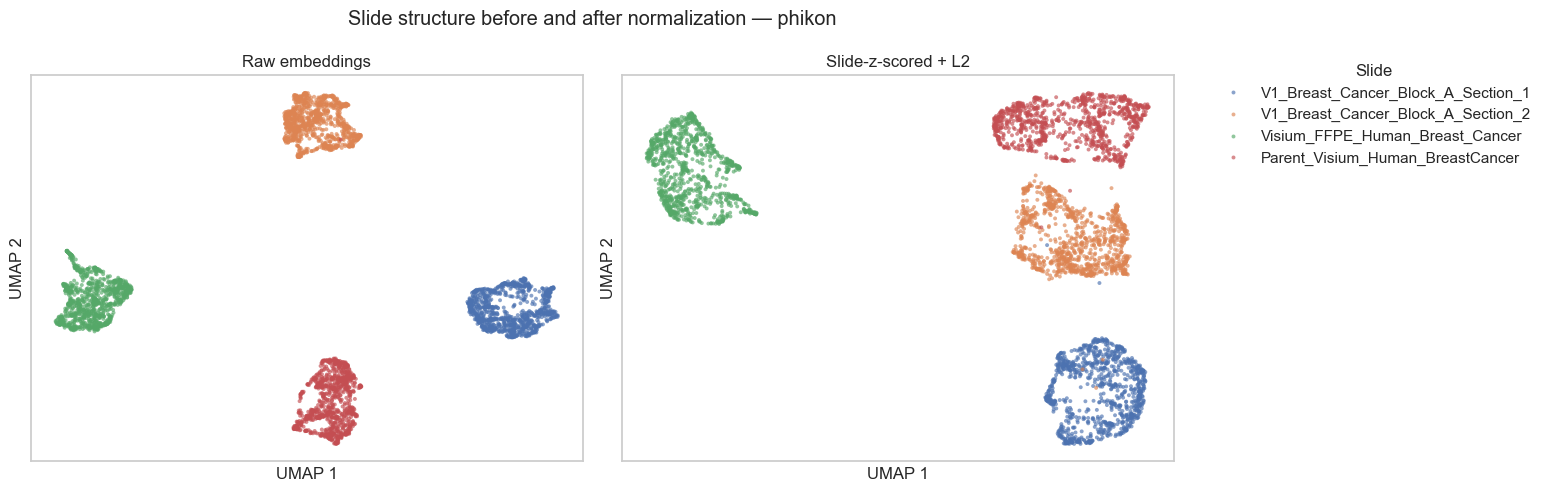

,model,preprocessing,slide_silhouette
0,phikon,raw,0.357
1,phikon,slide_zscore_l2,-0.001


In [9]:
from sklearn.decomposition import PCA
import umap

diagnostic_model = summary.sort_values("mean_macro_f1", ascending=False).iloc[0]["model"]
slide_data = all_model_data[diagnostic_model]
rng = np.random.default_rng(SEED)
sample_parts, sample_meta = [], []
for slide_id in slides:
    embeddings, metadata = slide_data[slide_id]
    n = min(1000, len(metadata))
    idx = np.sort(rng.choice(len(metadata), n, replace=False))
    sample_parts.append((embeddings[idx], slide_id))
    sample_meta.append(metadata.iloc[idx][["slide_id", "tme_class"]])
meta = pd.concat(sample_meta, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
silhouette_rows = []
for ax, mode, title in zip(axes, ["raw", "slide_zscore_l2"], ["Raw embeddings", "Slide-z-scored + L2"]):
    transformed = np.concatenate([preprocess_slide_embeddings(x, mode) for x, _ in sample_parts])
    pca = PCA(n_components=min(50, transformed.shape[1]), random_state=SEED).fit_transform(transformed)
    coords = umap.UMAP(n_neighbors=30, min_dist=.2, random_state=SEED, n_jobs=1).fit_transform(pca)
    view = meta.copy(); view[["UMAP1", "UMAP2"]] = coords
    sns.scatterplot(data=view, x="UMAP1", y="UMAP2", hue="slide_id", s=8, alpha=.65, linewidth=0, ax=ax)
    ax.set(title=title, xticks=[], yticks=[], xlabel="UMAP 1", ylabel="UMAP 2"); ax.grid(False)
    ax.legend().remove()
    silhouette_rows.append({
        "model": diagnostic_model,
        "preprocessing": mode,
        "slide_silhouette": silhouette_score(pca[:, :20], meta["slide_id"]),
    })
handles, labels_ = axes[1].get_legend_handles_labels()
fig.legend(handles, labels_, title="Slide", bbox_to_anchor=(1.01, .9), loc="upper left", frameon=False)
plt.suptitle(f"Slide structure before and after normalization — {diagnostic_model}")
plt.tight_layout()
plt.savefig(figure_dir / "06_normalization_umap.png", dpi=170, bbox_inches="tight")
plt.show()
display(pd.DataFrame(silhouette_rows).round(3))

## Checks

In [10]:
checks = {
    "two_encoders_complete": set(audit.model) == set(model_names) and len(audit) == 8,
    "all_embeddings_finite": all(np.isfinite(x).all() for model in all_model_data.values() for x, _ in model.values()),
    "four_outer_folds_per_experiment": results.groupby(["model", "task"]).size().eq(4).all(),
    "held_out_slides_unique": results.groupby(["model", "task"])["held_out_slide"].nunique().eq(4).all(),
    "nested_settings_recorded": results["selected_candidate"].notna().all(),
    "majority_baselines_recorded": results["majority_macro_f1"].notna().all(),
    "three_class_coverage_explicit": results.loc[results.task == "confident_3class", "coverage"].lt(1).all(),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())

,passed
two_encoders_complete,True
all_embeddings_finite,True
four_outer_folds_per_experiment,True
held_out_slides_unique,True
nested_settings_recorded,True
majority_baselines_recorded,True
three_class_coverage_explicit,True


## Takeaways

1. **The original low score was partly an evaluation/preprocessing problem.** The
   nested all-class Kaiko result is 0.294, substantially above the initial raw
   probe result (0.141), without changing any encoder weights.
2. **Phikon transfers better on this cohort.** It improves mean macro-F1 over Kaiko
   by 0.026 on all four labels and 0.039 on the confident three-class task.
3. **Label confidence matters more than another small model swap.** Removing
   `other` gives Phikon 0.366 macro-F1, but discards 61.0% of spots; it is a
   selective high-confidence task, not a directly comparable replacement metric.
4. **Batch correction is incomplete.** Slide z-scoring + L2 was selected in every
   all-class outer fold and lowers the linear PCA slide silhouette from 0.357 to
   -0.001. The UMAP still separates slides, however, revealing residual nonlinear
   domain shift.
5. **Treat the ranking as preliminary.** There are only four slides, two are
   adjacent sections from one patient, labels are heuristic, and both encoders use
   non-commercial research weights.

### Next steps

1. Replace heuristic cluster annotations with consistent expert or molecular-rule labels.
2. Add independent patients and institutions before any fine-tuning.
3. Test multiscale and spatial-neighbor embedding aggregation.
4. Evaluate commercially permissible encoders after governance review.